In [95]:
#!pip install polars
#!pip install xlsxwriter

In [96]:
from IPython import get_ipython
get_ipython().run_line_magic('reset', '-f')

# Import datasets


In [97]:
import polars as pl

general_information = pl.read_csv('data/general_information_bkp.csv', infer_schema_length=None, ignore_errors=True)
type_and_level = pl.read_csv('data/type_and_level_bk.csv', infer_schema_length=None, ignore_errors=True)
geographical_facilities = pl.read_csv('data/geographical_facilities_bkp.csv', infer_schema_length=None, ignore_errors=True)
buildings_and_library = pl.read_csv('data/buildings_and_library.csv', infer_schema_length=None, ignore_errors=True)
compliance1 = pl.read_csv('data/compliance_1_bkp.csv', infer_schema_length=None, ignore_errors=True)
compliance2 = pl.read_csv('data/compliance_2_bkp.csv', infer_schema_length=None, ignore_errors=True)
compliance3 = pl.read_csv('data/compliance_3_bkp.csv', infer_schema_length=None, ignore_errors=True)
compliance4 = pl.read_csv('data/compliance_4_bkp.csv', infer_schema_length=None, ignore_errors=True)
divisions = pl.read_csv('data/divisions_bkp.csv', infer_schema_length=None, ignore_errors=True)
districts = pl.read_csv('data/districts_bkp.csv', infer_schema_length=None, ignore_errors=True)
thanas = pl.read_csv('data/thanas_bkp.csv', infer_schema_length=None, ignore_errors=True)
pbgsi_institutions = pl.read_csv('data/pbgsi_7000_ins_bkp.csv', infer_schema_length=None, ignore_errors=True)
institute_type = pl.read_csv('configs/institution_type.csv', infer_schema_length=None, ignore_errors=True)
student_type = pl.read_csv('configs/student_types.csv', infer_schema_length=None, ignore_errors=True)
divisions = pl.read_csv('data/divisions_bkp.csv', infer_schema_length=None, ignore_errors=True)
districts = pl.read_csv('data/districts_bkp.csv', infer_schema_length=None, ignore_errors=True)
thanas = pl.read_csv('data/thanas_bkp.csv', infer_schema_length=None, ignore_errors=True)
approval_status = pl.read_csv('configs/approval_status.csv', infer_schema_length=None, ignore_errors=True)
boards = pl.read_csv('configs/boards.csv', infer_schema_length=None, ignore_errors=True)
boundary_types = pl.read_csv('configs/boundary_type.csv', infer_schema_length=None, ignore_errors=True)
emis_submission_types = pl.read_csv('configs/emis_submission_types.csv', infer_schema_length=None, ignore_errors=True)
fiscal_years = pl.read_csv('configs/fiscal_years.csv', infer_schema_length=None, ignore_errors=True)
geographical_location_types = pl.read_csv('configs/geographical_locations_type.csv', infer_schema_length=None, ignore_errors=True)
highest_levels = pl.read_csv('configs/higest_levels.csv',infer_schema_length=None, ignore_errors=True)
management_type = pl.read_csv('configs/management_types.csv', infer_schema_length=None, ignore_errors=True)
mpo_status = pl.read_csv('configs/mpo_status.csv', infer_schema_length=None, ignore_errors=True)
ownership_types = pl.read_csv('configs/ownership_type.csv', infer_schema_length=None, ignore_errors=True)
pass_rate_types = pl.read_csv('configs/pass_rate_type.csv', infer_schema_length=None, ignore_errors=True)
sexual_harassment_committee_activity_type = pl.read_csv('configs/sexual_harassment_committee_activity_type.csv', infer_schema_length=None, ignore_errors=True)
students_attendance_types = pl.read_csv('configs/students_attendance_type.csv', infer_schema_length=None, ignore_errors=True)
teachers_attendance_types = pl.read_csv('configs/teachers_attendance_type.csv', infer_schema_length=None, ignore_errors=True)
technical_types = pl.read_csv('configs/technical_type.csv', infer_schema_length=None, ignore_errors=True)
ward_type = pl.read_csv('configs/ward_type.csv', infer_schema_length=None, ignore_errors=True)

# Generate Column Names

In [98]:
df_vars = {
    name: val
    for name, val  in globals().items()
    if isinstance(val, (pl.DataFrame, pl.LazyFrame))
}

In [99]:
from pathlib import Path

out_dir = Path.cwd() / "generate"
out_dir.mkdir(parents=True, exist_ok=True)

In [100]:
for name, val  in df_vars.items():
    with open("generate/" + name +".py", "w") as f:
        for col in val.columns:
            safe_col = col.strip().replace(" ", "_").replace("-","_").replace("[","").replace("]","")
            f.write(f'{safe_col.upper()}="{col}"\n')

In [101]:
import importlib

def update_columns(dataframe_name: str):
    df_vars = {
    name: val
    for name, val  in globals().items()
    if isinstance(val, (pl.DataFrame, pl.LazyFrame))
    }
    for name, val  in df_vars.items():
        if name == dataframe_name:
            print('found match')
            with open("generate/" + name +".py", "w") as f:
                for col in val.columns:
                    safe_col = col.strip().replace(" ", "_").replace("-","_").replace("[","").replace("]","")
                    f.write(f'{safe_col.upper()}="{col}"\n')
            print('column names updated')
            module = importlib.import_module('generate.'+dataframe_name)
            importlib.reload(module)

Consider only submitted institutions

In [102]:
from generate.general_information import SUBMITTED

general_information = general_information.filter(pl.col(SUBMITTED) == 1)

Join general information with Type and Level, Geographical Facilities, Compliance1, Compliance2, Compliance3, Compliance4

In [103]:
general_information = general_information.join(type_and_level, left_on=general_information['eiin'].name, right_on=type_and_level['eiin'].name, how="inner", suffix='_type_and_level')
general_information = general_information.join(geographical_facilities, left_on=general_information['eiin'].name, right_on=geographical_facilities['eiin'].name, how="inner", suffix='_geographical_facilities')
general_information = general_information.join(compliance1, left_on=general_information['eiin'].name, right_on=compliance1['eiin'].name, how='inner', suffix='_compliance1')
general_information = general_information.join(compliance2, left_on=general_information['eiin'].name, right_on=compliance2['eiin'].name, how='inner', suffix='_compliance2')
general_information = general_information.join(compliance3, left_on=general_information['eiin'].name, right_on=compliance3['eiin'].name, how='left', suffix='_compliance3')
general_information = general_information.join(compliance4, left_on=general_information['eiin'].name, right_on=compliance4['eiin'].name, how='inner', suffix='_compliance4')

Update the generated column names of general_information

In [104]:
update_columns('general_information')

found match
column names updated


Filter only pubgsi submitted institutions

In [105]:
from generate.general_information import PBGSI_SCHEME

general_information = general_information.filter(pl.col(PBGSI_SCHEME) == True)

Join general_information with institute_type, student_type, divisions, districts, thanas, geographical_location_types

In [106]:
general_information = general_information.join(institute_type, left_on=general_information['institution_type'].name, right_on=institute_type['institute_type_id'].name, how='inner', suffix='_institution_type')
general_information = general_information.join(student_type, left_on=general_information['student_type'].name, right_on=student_type['student_type_id'].name, how='inner', suffix='_student_type')
general_information = general_information.join(divisions, left_on=general_information['address_division'].name, right_on=divisions['division_id'].name, how='inner', suffix='_division')
general_information = general_information.join(districts, left_on=general_information['address_district'].name, right_on=districts['district_id'].name, how='inner', suffix='_district')
general_information = general_information.join(thanas, left_on=general_information['address_thana'].name, right_on=thanas['thana_id'].name, how='inner', suffix='_thana')
general_information = general_information.join(geographical_location_types, left_on=geographical_facilities['geographical_position'].name, right_on=geographical_location_types['geographical_location_id'].name, how='inner', suffix='_geographical_location_type')

In [107]:
update_columns('general_information')

found match
column names updated


In [108]:
general_information.head(5)

id,institution_name_bangla,institution_name_english,address_village_holding,address_road,address_post_office,address_post_code,[union],address_ward,address_thana,address_district,address_division,mobile_number,picture,latitude,longitude,ownership_type,is_owned_land,has_deed,has_mutation,pays_taxes,academic_activities_running,eiin_yes_no,eiin,non_eiin_id,horizontal_accuracy,vertical_accuracy,position_time,inst_category,establishment_date,union_ward,municipility,municipility_ward,union,city_corporation,city_corporation_ward,ward_type,…,ninth_grade_books_issued_count,ninth_grade_books_received,tenth_grade_books_issued_count,tenth_grade_books_received,manual_distributed,distribution_info_sent,visited,visited_by_monitoring_officer,visited_by_scheme_officer,visited_by_maushi,visited_by_others,books_received_on,sixth_grade_books_provided,seventh_grade_books_provided,eighth_grade_books_provided,ninth_grade_books_provided,tenth_grade_books_provided,institute_type_name,institute_type_name_en,student_type_name,student_type_name_en,division_id_legacy,division_name,division_name_bn,division_code,district_id_legacy,district_name,district_name_bn,division_id,district_code,thana_code,thana_id_legacy,thana_name,thana_name_bn,district_id,city_corp,geographical_location_name
i64,str,str,str,str,str,str,str,str,i64,i64,i64,str,str,f64,f64,str,bool,bool,bool,bool,bool,str,str,i64,f64,f64,str,i64,str,str,str,i64,str,str,i64,bool,…,i64,i64,i64,i64,bool,bool,bool,bool,bool,bool,bool,str,i64,i64,i64,i64,i64,str,str,str,str,i64,str,str,i64,i64,str,str,i64,i64,str,i64,str,str,i64,str,str
199041,"""তেলিখাল উচ্চ বিদ্যালয়""","""TELIKHAL HIGH SCHOOL""","""TELEKHAL""",null,null,null,null,null,129,63,7,"""01309130228""","""130228_20250811_044030.jpg""",25.074261,91.77726,"""OWN""",false,true,true,true,true,null,"""130228""",null,9.483,7.418218,null,1,"""01-01-1998""",null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশিক্ষা""","""Co-education""",60,"""Sylhet""","""সিলেট""",6,6091,"""Sylhet""","""সিলেট""",7,91,"""6091""",609127,"""Companiganj""","""কোম্পানীগঞ্জ""",63,null,"""হাওড়/ বিল"""
194031,"""উজগ্রাম পিন্টু বালিকা উচ্চ বিদ…","""UZGRAM PINTU GIRLS HIGH SCHOOL""","""UZGRAM""","""0""","""Langluhat""","""5820""",null,null,184,7,6,"""01309119506""","""119506_20250811_053432.jpg""",24.988141,89.428448,"""OWN""",false,true,true,true,true,null,"""119506""",null,4.7,20.734821,null,1,"""14-01-1987""","""8""",null,null,"""11 num.Dakkhinpara""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""মেয়ে""","""Girl""",50,"""Rajshahi""","""রাজশাহী""",5,5010,"""Bogura""","""বগুড়া""",6,10,"""5010""",501040,"""Gabtali""","""গাবতলী""",7,null,"""সমতল """
195117,"""কৃষ্ণারডাঙ্গী উচ্চ বিদ্যালয়""","""KRISHNAR DANGI HIGH SCHOOL""","""KRISHNAR DANGI""","""Faridpur Sadarpur Road""","""Kunjanagar""","""7821""",null,null,383,16,4,"""01309108863""","""108863_20250811_080457.jpg""",23.554668,89.90374,"""OWN""",false,true,true,true,true,null,"""108863""",null,4.3,2.305418,null,1,"""01-01-1960""","""2""",null,null,"""Ramnagar""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশিক্ষা""","""Co-education""",30,"""Dhaka""","""ঢাকা""",3,3029,"""Faridpur""","""ফরিদপুর""",4,29,"""3029""",302962,"""Nagarkanda""","""নগরকান্দা""",16,null,"""সমতল """
218067,"""রাঙ্গামূলারকান্দি হাজী আব্দুল্…","""RANGAMULAR KANDI HAZI ABDULLAH…","""RANGAMULAR KANDI""","""Rangamular kandi""","""Shriangan""","""7804""",null,null,92,16,4,"""01309108676""","""108676_20250811_055124.jpg""",23.442474,89.708453,"""OWN""",false,true,true,true,true,null,"""108676""",null,9.0,4.217729,null,1,"""01-01-1965""","""7""",null,null,"""Dadpur""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""স

In [109]:
general_information['institute_type_name_en'].head()

institute_type_name_en
str
"""SCHOOL"""
"""SCHOOL"""
"""SCHOOL"""
"""SCHOOL"""
"""SCHOOL"""
"""SCHOOL"""
"""SCHOOL"""
"""MADRASHA"""
"""SCHOOL"""


Merge college and school & college for the purpose of the report

In [110]:
# first we copy the columns to new columns
general_information = general_information.with_columns([
    pl.col('institution_type').alias('generalized_institution_type_id'),
    pl.col('institute_type_name_en').alias('generalized_institution_type_name_en')
])

In [111]:
general_information.head()

id,institution_name_bangla,institution_name_english,address_village_holding,address_road,address_post_office,address_post_code,[union],address_ward,address_thana,address_district,address_division,mobile_number,picture,latitude,longitude,ownership_type,is_owned_land,has_deed,has_mutation,pays_taxes,academic_activities_running,eiin_yes_no,eiin,non_eiin_id,horizontal_accuracy,vertical_accuracy,position_time,inst_category,establishment_date,union_ward,municipility,municipility_ward,union,city_corporation,city_corporation_ward,ward_type,…,tenth_grade_books_issued_count,tenth_grade_books_received,manual_distributed,distribution_info_sent,visited,visited_by_monitoring_officer,visited_by_scheme_officer,visited_by_maushi,visited_by_others,books_received_on,sixth_grade_books_provided,seventh_grade_books_provided,eighth_grade_books_provided,ninth_grade_books_provided,tenth_grade_books_provided,institute_type_name,institute_type_name_en,student_type_name,student_type_name_en,division_id_legacy,division_name,division_name_bn,division_code,district_id_legacy,district_name,district_name_bn,division_id,district_code,thana_code,thana_id_legacy,thana_name,thana_name_bn,district_id,city_corp,geographical_location_name,generalized_institution_type_id,generalized_institution_type_name_en
i64,str,str,str,str,str,str,str,str,i64,i64,i64,str,str,f64,f64,str,bool,bool,bool,bool,bool,str,str,i64,f64,f64,str,i64,str,str,str,i64,str,str,i64,bool,…,i64,i64,bool,bool,bool,bool,bool,bool,bool,str,i64,i64,i64,i64,i64,str,str,str,str,i64,str,str,i64,i64,str,str,i64,i64,str,i64,str,str,i64,str,str,i64,str
199041,"""তেলিখাল উচ্চ বিদ্যালয়""","""TELIKHAL HIGH SCHOOL""","""TELEKHAL""",null,null,null,null,null,129,63,7,"""01309130228""","""130228_20250811_044030.jpg""",25.074261,91.77726,"""OWN""",false,true,true,true,true,null,"""130228""",null,9.483,7.418218,null,1,"""01-01-1998""",null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশিক্ষা""","""Co-education""",60,"""Sylhet""","""সিলেট""",6,6091,"""Sylhet""","""সিলেট""",7,91,"""6091""",609127,"""Companiganj""","""কোম্পানীগঞ্জ""",63,null,"""হাওড়/ বিল""",1,"""SCHOOL"""
194031,"""উজগ্রাম পিন্টু বালিকা উচ্চ বিদ…","""UZGRAM PINTU GIRLS HIGH SCHOOL""","""UZGRAM""","""0""","""Langluhat""","""5820""",null,null,184,7,6,"""01309119506""","""119506_20250811_053432.jpg""",24.988141,89.428448,"""OWN""",false,true,true,true,true,null,"""119506""",null,4.7,20.734821,null,1,"""14-01-1987""","""8""",null,null,"""11 num.Dakkhinpara""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""মেয়ে""","""Girl""",50,"""Rajshahi""","""রাজশাহী""",5,5010,"""Bogura""","""বগুড়া""",6,10,"""5010""",501040,"""Gabtali""","""গাবতলী""",7,null,"""সমতল """,1,"""SCHOOL"""
195117,"""কৃষ্ণারডাঙ্গী উচ্চ বিদ্যালয়""","""KRISHNAR DANGI HIGH SCHOOL""","""KRISHNAR DANGI""","""Faridpur Sadarpur Road""","""Kunjanagar""","""7821""",null,null,383,16,4,"""01309108863""","""108863_20250811_080457.jpg""",23.554668,89.90374,"""OWN""",false,true,true,true,true,null,"""108863""",null,4.3,2.305418,null,1,"""01-01-1960""","""2""",null,null,"""Ramnagar""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশিক্ষা""","""Co-education""",30,"""Dhaka""","""ঢাকা""",3,3029,"""Faridpur""","""ফরিদপুর""",4,29,"""3029""",302962,"""Nagarkanda""","""নগরকান্দা""",16,null,"""সমতল """,1,"""SCHOOL"""
218067,"""রাঙ্গামূলারকান্দি হাজী আব্দুল্…","""RANGAMULAR KANDI HAZI ABDULLAH…","""RANGAMULAR KANDI""","""Rangamular kandi""","""Shriangan""","""7804""",null,null,92,16,4,"""01309108676""","""108676_20250811_055124.jpg""",23.442474,89.708453,"""OWN""",false,true,true,true,true,null,"""108676""",null,9.0,4.217729,null,1,"""01-01-1965""","""7""",null,null,"""Dadpur""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","

In [112]:

# when we get the college type, we change the type to school & college

condition = pl.col(general_information['generalized_institution_type_id'].name)==3

general_information = general_information.with_columns([
    pl.when(condition)
    .then(pl.lit(2))
    .otherwise(pl.col(general_information['generalized_institution_type_id'].name))
    .alias('generalized_institution_type_id'),
    
    pl.when(condition)
    .then(pl.lit('SCHOOL AND COLLEGE'))
    .otherwise(pl.col(general_information['generalized_institution_type_name_en'].name))
    .alias('generalized_institution_type_name_en')
])

In [113]:
general_information.head()

id,institution_name_bangla,institution_name_english,address_village_holding,address_road,address_post_office,address_post_code,[union],address_ward,address_thana,address_district,address_division,mobile_number,picture,latitude,longitude,ownership_type,is_owned_land,has_deed,has_mutation,pays_taxes,academic_activities_running,eiin_yes_no,eiin,non_eiin_id,horizontal_accuracy,vertical_accuracy,position_time,inst_category,establishment_date,union_ward,municipility,municipility_ward,union,city_corporation,city_corporation_ward,ward_type,…,tenth_grade_books_issued_count,tenth_grade_books_received,manual_distributed,distribution_info_sent,visited,visited_by_monitoring_officer,visited_by_scheme_officer,visited_by_maushi,visited_by_others,books_received_on,sixth_grade_books_provided,seventh_grade_books_provided,eighth_grade_books_provided,ninth_grade_books_provided,tenth_grade_books_provided,institute_type_name,institute_type_name_en,student_type_name,student_type_name_en,division_id_legacy,division_name,division_name_bn,division_code,district_id_legacy,district_name,district_name_bn,division_id,district_code,thana_code,thana_id_legacy,thana_name,thana_name_bn,district_id,city_corp,geographical_location_name,generalized_institution_type_id,generalized_institution_type_name_en
i64,str,str,str,str,str,str,str,str,i64,i64,i64,str,str,f64,f64,str,bool,bool,bool,bool,bool,str,str,i64,f64,f64,str,i64,str,str,str,i64,str,str,i64,bool,…,i64,i64,bool,bool,bool,bool,bool,bool,bool,str,i64,i64,i64,i64,i64,str,str,str,str,i64,str,str,i64,i64,str,str,i64,i64,str,i64,str,str,i64,str,str,i64,str
199041,"""তেলিখাল উচ্চ বিদ্যালয়""","""TELIKHAL HIGH SCHOOL""","""TELEKHAL""",null,null,null,null,null,129,63,7,"""01309130228""","""130228_20250811_044030.jpg""",25.074261,91.77726,"""OWN""",false,true,true,true,true,null,"""130228""",null,9.483,7.418218,null,1,"""01-01-1998""",null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশিক্ষা""","""Co-education""",60,"""Sylhet""","""সিলেট""",6,6091,"""Sylhet""","""সিলেট""",7,91,"""6091""",609127,"""Companiganj""","""কোম্পানীগঞ্জ""",63,null,"""হাওড়/ বিল""",1,"""SCHOOL"""
194031,"""উজগ্রাম পিন্টু বালিকা উচ্চ বিদ…","""UZGRAM PINTU GIRLS HIGH SCHOOL""","""UZGRAM""","""0""","""Langluhat""","""5820""",null,null,184,7,6,"""01309119506""","""119506_20250811_053432.jpg""",24.988141,89.428448,"""OWN""",false,true,true,true,true,null,"""119506""",null,4.7,20.734821,null,1,"""14-01-1987""","""8""",null,null,"""11 num.Dakkhinpara""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""মেয়ে""","""Girl""",50,"""Rajshahi""","""রাজশাহী""",5,5010,"""Bogura""","""বগুড়া""",6,10,"""5010""",501040,"""Gabtali""","""গাবতলী""",7,null,"""সমতল """,1,"""SCHOOL"""
195117,"""কৃষ্ণারডাঙ্গী উচ্চ বিদ্যালয়""","""KRISHNAR DANGI HIGH SCHOOL""","""KRISHNAR DANGI""","""Faridpur Sadarpur Road""","""Kunjanagar""","""7821""",null,null,383,16,4,"""01309108863""","""108863_20250811_080457.jpg""",23.554668,89.90374,"""OWN""",false,true,true,true,true,null,"""108863""",null,4.3,2.305418,null,1,"""01-01-1960""","""2""",null,null,"""Ramnagar""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশিক্ষা""","""Co-education""",30,"""Dhaka""","""ঢাকা""",3,3029,"""Faridpur""","""ফরিদপুর""",4,29,"""3029""",302962,"""Nagarkanda""","""নগরকান্দা""",16,null,"""সমতল """,1,"""SCHOOL"""
218067,"""রাঙ্গামূলারকান্দি হাজী আব্দুল্…","""RANGAMULAR KANDI HAZI ABDULLAH…","""RANGAMULAR KANDI""","""Rangamular kandi""","""Shriangan""","""7804""",null,null,92,16,4,"""01309108676""","""108676_20250811_055124.jpg""",23.442474,89.708453,"""OWN""",false,true,true,true,true,null,"""108676""",null,9.0,4.217729,null,1,"""01-01-1965""","""7""",null,null,"""Dadpur""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","

In [114]:
student_type.head()

student_type_id,student_type_name,student_type_name_en
i64,str,str
1,"""ছেলে""","""Boy"""
2,"""মেয়ে""","""Girl"""
3,"""সহশিক্ষা""","""Co-education"""


## Table 1. Number of secondary institutions havign management accoutability grant by type of institution and gender composition
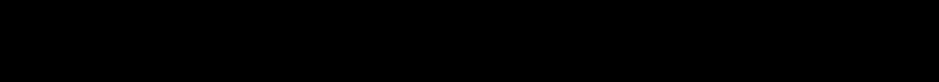
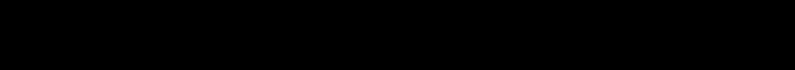
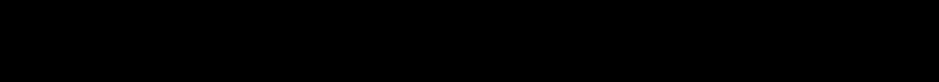

In [115]:
report1 = (
    general_information.lazy()
    .group_by(pl.col('generalized_institution_type_name_en').alias('institution_type'))
    .agg([
         pl.len().alias('total'),
         (pl.col('student_type')==1).sum().alias('total_boys'),
         (pl.col('student_type')==2).sum().alias('total_girls'),
         (pl.col('student_type')==3).sum().alias('co-education')
    ])
)

report1_df = report1.collect()
report1_df.head(100)

institution_type,total,total_boys,total_girls,co-education
str,u32,u32,u32,u32
"""SCHOOL AND COLLEGE""",625,2,90,533
"""QAOMI MADRASHA""",15,7,6,2
"""MADRASHA""",2045,7,179,1859
"""TECHNICAL AND VOCATIONAL""",28,0,1,27
"""SCHOOL""",5623,63,800,4760


In [116]:
report1_df.write_excel('output/table1.xlsx')

## Table 2. Distribution of secondary institutions having Management Accountability Grant by Division and type of institution

In [117]:
institute_type.head(10)

institute_type_id,institute_type_name,institute_type_name_en
i64,str,str
1,"""স্কুল""","""SCHOOL"""
2,"""স্কুল এন্ড কলেজ""","""SCHOOL AND COLLEGE"""
3,"""কলেজ""","""COLLEGE"""
4,"""মাদ্রাসা""","""MADRASHA"""
5,"""কওমী মাদ্রাসা""","""QAOMI MADRASHA"""
6,"""কারিগরি ও ভোকেশনাল""","""TECHNICAL AND VOCATIONAL"""


In [118]:
from generate.general_information import DIVISION_NAME, INSTITUTION_TYPE
institution_type_school = 1
institution_type_school_and_college = 2
institution_type_madrasha = 4

report2 = (
    general_information.lazy()
    .group_by(pl.col(DIVISION_NAME).alias("Division"))
    .agg([
      (pl.col(INSTITUTION_TYPE)== institution_type_school).sum().alias('Secondary School'),
      (pl.col(INSTITUTION_TYPE)==institution_type_school_and_college).sum().alias('School & College'),
      (pl.col(INSTITUTION_TYPE)== institution_type_madrasha).sum().alias('Madrasha')
    ])
)

report2_df = report2.collect()
report2_df.head(10)

Division,Secondary School,School & College,Madrasha
str,u32,u32,u32
"""Sylhet""",316,81,107
"""Dhaka""",1112,143,331
"""Barishal""",630,42,340
"""Chattogram""",1080,90,393
"""Rangpur""",714,66,226
"""Khulna""",763,48,204
"""Rajshahi""",650,59,300
"""Mymensingh""",358,30,144


Add percentage

In [119]:
report2_df = report2_df.with_columns([
    ((pl.col('Secondary School')/(pl.col('Secondary School') + pl.col('School & College') + pl.col('Madrasha'))) * 100).round(2).alias('school percentage'),
    ((pl.col('School & College')/(pl.col('Secondary School') + pl.col('School & College') + pl.col('Madrasha'))) * 100).round(2).alias('school & college percentage'),
    ((pl.col('Madrasha')/(pl.col('Secondary School') + pl.col('School & College') + pl.col('Madrasha'))) * 100).round(2).alias('madrasha percentage')
])

In [120]:
report2_df.head(10)

Division,Secondary School,School & College,Madrasha,school percentage,school & college percentage,madrasha percentage
str,u32,u32,u32,f64,f64,f64
"""Sylhet""",316,81,107,62.7,16.07,21.23
"""Dhaka""",1112,143,331,70.11,9.02,20.87
"""Barishal""",630,42,340,62.25,4.15,33.6
"""Chattogram""",1080,90,393,69.1,5.76,25.14
"""Rangpur""",714,66,226,70.97,6.56,22.47
"""Khulna""",763,48,204,75.17,4.73,20.1
"""Rajshahi""",650,59,300,64.42,5.85,29.73
"""Mymensingh""",358,30,144,67.29,5.64,27.07


In [121]:
report2_df = report2_df.sort('Division', descending=False)

In [122]:
report2_df.head(10)

Division,Secondary School,School & College,Madrasha,school percentage,school & college percentage,madrasha percentage
str,u32,u32,u32,f64,f64,f64
"""Barishal""",630,42,340,62.25,4.15,33.6
"""Chattogram""",1080,90,393,69.1,5.76,25.14
"""Dhaka""",1112,143,331,70.11,9.02,20.87
"""Khulna""",763,48,204,75.17,4.73,20.1
"""Mymensingh""",358,30,144,67.29,5.64,27.07
"""Rajshahi""",650,59,300,64.42,5.85,29.73
"""Rangpur""",714,66,226,70.97,6.56,22.47
"""Sylhet""",316,81,107,62.7,16.07,21.23


In [123]:
report2_df = report2_df.select(['Division', 'Secondary School', 'school percentage', 'School & College', 'school & college percentage', 'Madrasha', 'madrasha percentage'])

In [124]:
report2_df.head(10)

Division,Secondary School,school percentage,School & College,school & college percentage,Madrasha,madrasha percentage
str,u32,f64,u32,f64,u32,f64
"""Barishal""",630,62.25,42,4.15,340,33.6
"""Chattogram""",1080,69.1,90,5.76,393,25.14
"""Dhaka""",1112,70.11,143,9.02,331,20.87
"""Khulna""",763,75.17,48,4.73,204,20.1
"""Mymensingh""",358,67.29,30,5.64,144,27.07
"""Rajshahi""",650,64.42,59,5.85,300,29.73
"""Rangpur""",714,70.97,66,6.56,226,22.47
"""Sylhet""",316,62.7,81,16.07,107,21.23


In [125]:
report2_df.write_excel('output/table2.xlsx')

## Table 3. Number of Secondary Institutions received Management Accountability Grant having Toilet Facilities for students by type of institution

In [134]:
from generate.general_information import INSTITUTE_TYPE_NAME_EN, HAS_STUDENT_TOILET, TOTAL_TOILET_FOR_BOYS, TOTAL_TOILET_FOR_GIRLS, TOTAL_TOILET_FOR_SPECIAL_NEEDS

report3 = (
    general_information.lazy()
    .group_by(pl.col(INSTITUTE_TYPE_NAME_EN).alias('institution_type'))
    .agg([
        (pl.col(HAS_STUDENT_TOILET)==1).sum().alias('toilet_yes'),
        (pl.col(HAS_STUDENT_TOILET)==0).sum().alias('toilet_no'),
        (pl.col(TOTAL_TOILET_FOR_BOYS)==1).sum().alias('boys_1'),
        (pl.col(TOTAL_TOILET_FOR_BOYS)==2).sum().alias('boys_2'),
        (pl.col(TOTAL_TOILET_FOR_BOYS)>2).sum().alias('boys_2_plus'),
        (pl.col(TOTAL_TOILET_FOR_BOYS).is_null() | pl.col(TOTAL_TOILET_FOR_BOYS)==0).sum().alias('boys_none'),
        (pl.col(TOTAL_TOILET_FOR_GIRLS)==1).sum().alias('girls_1'),
        (pl.col(TOTAL_TOILET_FOR_GIRLS)==2).sum().alias('girls_2'),
        (pl.col(TOTAL_TOILET_FOR_GIRLS)>2).sum().alias('girls_2_plus'),
        (pl.col(TOTAL_TOILET_FOR_GIRLS).is_null() | pl.col(TOTAL_TOILET_FOR_GIRLS)==0).sum().alias('girls_none'),
        (pl.col(TOTAL_TOILET_FOR_SPECIAL_NEEDS)>=1).sum().alias('special_needs_toilet'),
        (pl.col(TOTAL_TOILET_FOR_SPECIAL_NEEDS).is_null() | pl.col(TOTAL_TOILET_FOR_SPECIAL_NEEDS)==0).sum().alias('special_needs_none')
    ])
)

report3_df = report3.collect()
report3_df.head(100)

institution_type,toilet_yes,toilet_no,boys_1,boys_2,boys_2_plus,boys_none,girls_1,girls_2,girls_2_plus,girls_none,special_needs_toilet,special_needs_none
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""SCHOOL""",5582,41,846,1246,2645,849,913,1281,3296,96,1679,3906
"""QAOMI MADRASHA""",12,3,2,0,5,5,2,2,3,5,1,11
"""COLLEGE""",66,0,18,13,29,6,17,18,30,1,14,52
"""SCHOOL AND COLLEGE""",558,1,37,75,358,88,43,85,426,4,183,375
"""MADRASHA""",2032,13,520,516,805,194,570,601,844,20,505,1529
"""TECHNICAL AND VOCATIONAL""",27,1,11,9,5,2,9,10,7,1,6,21


In [136]:
report3_df.write_excel('output/table3.xlsx')

## Table 4. Number of Secondary Institutions received Management Accountability Grant having Toilet Facilities for teachers by type of institution

In [147]:
from generate.general_information import INSTITUTE_TYPE_NAME_EN, HAS_TEACHER_TOILET, TOTAL_TOILET_FOR_MALE_TEACHERS, TOTAL_TOILET_FOR_FEMALE_TEACHERS, TOTAL_TOILET_FOR_COMMONS

report4 = (
    general_information.lazy()
    .group_by(pl.col(INSTITUTE_TYPE_NAME_EN).alias('institution_type'))
    .agg([
        (pl.col(HAS_TEACHER_TOILET)==1).sum().alias('toilet_yes'),
        (pl.col(HAS_TEACHER_TOILET)==0).sum().alias('toilet_no'),
        (pl.col(TOTAL_TOILET_FOR_MALE_TEACHERS)==1).sum().alias('male_1'),
        (pl.col(TOTAL_TOILET_FOR_MALE_TEACHERS)>=2).sum().alias('male_2_plus'),
        (pl.col(TOTAL_TOILET_FOR_MALE_TEACHERS).is_null() | pl.col(TOTAL_TOILET_FOR_MALE_TEACHERS)==0).sum().alias('male_none'),
        (pl.col(TOTAL_TOILET_FOR_FEMALE_TEACHERS)==1).sum().alias('female_1'),
        (pl.col(TOTAL_TOILET_FOR_FEMALE_TEACHERS)>=2).sum().alias('female_2_plus'),
        (pl.col(TOTAL_TOILET_FOR_FEMALE_TEACHERS).is_null() | pl.col(TOTAL_TOILET_FOR_FEMALE_TEACHERS)==0 ).sum().alias('female_none'),
        (pl.col(TOTAL_TOILET_FOR_COMMONS)==1).sum().alias('common_1'),
        (pl.col(TOTAL_TOILET_FOR_COMMONS)>1).sum().alias('common_plus')
    ])
)

report4_df = report4.collect()

report4_df.head(10)

institution_type,toilet_yes,toilet_no,male_1,male_2_plus,male_none,female_1,female_2_plus,female_none,common_1,common_plus
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""COLLEGE""",66,0,23,36,7,32,25,9,27,18
"""SCHOOL""",5557,66,2321,2301,943,3139,1222,1204,2263,790
"""MADRASHA""",1999,46,931,845,230,1205,408,392,686,287
"""QAOMI MADRASHA""",11,4,6,5,0,3,1,7,0,0
"""SCHOOL AND COLLEGE""",558,1,148,354,56,272,216,70,195,109
"""TECHNICAL AND VOCATIONAL""",26,2,17,8,1,20,1,5,10,1


In [148]:
report4_df.write_excel('output/table4.xlsx')